In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [8]:
# model predictions for 20250923-1900
pangu_24h = xr.open_dataset("../../AI_forecasting_result/Ragasa/Pangu/output_24/2025-09-22-19-00to2025-09-24-19-00/upper_combined.nc")
graphcast_24h = xr.open_dataset("../../AI_forecasting_result/Ragasa/Graphcast/output_24/2025092219/gc_operational_predict_data_4.nc")
fengwu_24h = xr.open_dataset("../../AI_forecasting_result/Ragasa/Fengwu/output_24/2025-09-22-13-00_to_2025-09-22-19-00/decoded_output_3.nc")
fuxi_24h = xr.open_dataset("../../AI_forecasting_result/Ragasa/Fuxi/output_24/2025092213_to_2025092219/024.nc")
aurora_24h = xr.open_dataset("../../AI_forecasting_result/Ragasa/Aurora/output_24/WP/Ragasa/202509221300/20250923_190000.nc")

C:\Users\HF.DESKTOP-QSN0631\AppData\Local\Temp\ipykernel_16072\2280699983.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  graphcast_24h = xr.open_dataset("../../AI_forecasting_result/Ragasa/Graphcast/output_24/2025092219/gc_operational_predict_data_4.nc")


In [25]:
# ERA5 ground truth
era5_uv850_20250923_19 = xr.open_dataset("./data/era5_uv850_20250923-19.nc")

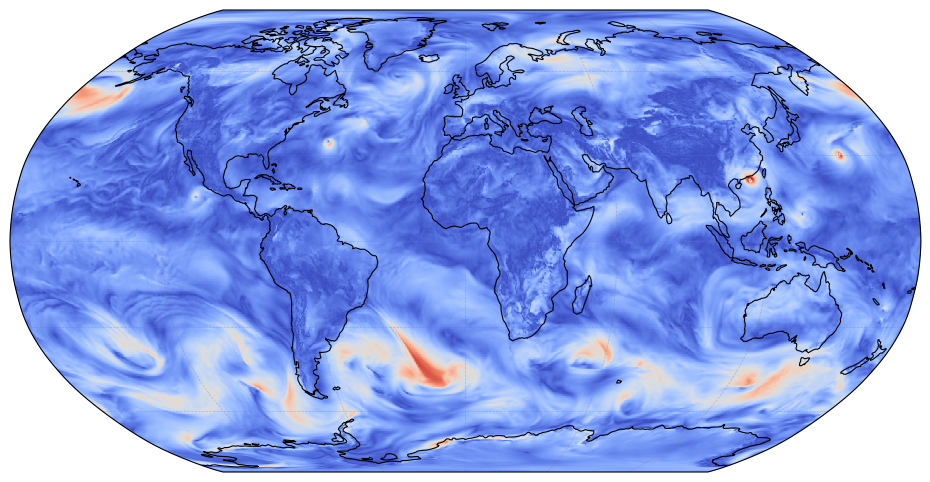

In [ ]:
# plot ERA5 wind speed at 850hPa
u850_era5 = era5_uv850_20250923_19.u.data.squeeze()
v850_era5 = era5_uv850_20250923_19.v.data.squeeze()
wspd850_era5 = np.sqrt(u850_era5**2 + v850_era5**2)

lat = era5_uv850_20250923_19.latitude.data
lon = era5_uv850_20250923_19.longitude.data
wspd850_era5_cyclic, lon_cyclic = add_cyclic_point(wspd850_era5, coord=lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
mesh = ax.pcolormesh(
    lon_cyclic,
    lat,
    wspd850_era5_cyclic,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    shading="auto",
)
ax.set_global()
ax.coastlines(linewidth=0.8)
# ax.gridlines(linewidth=0.5, color="gray", alpha=0.4, linestyle="--")

# cbar = plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, fraction=0.05)
# cbar.set_label("850 hPa wind speed (m s$^{-1}$)")
# ax.set_title("ERA5 850 hPa Wind Speed")
plt.savefig("wspd850_era5_2025092319.tif", dpi=600, bbox_inches='tight')
plt.show()

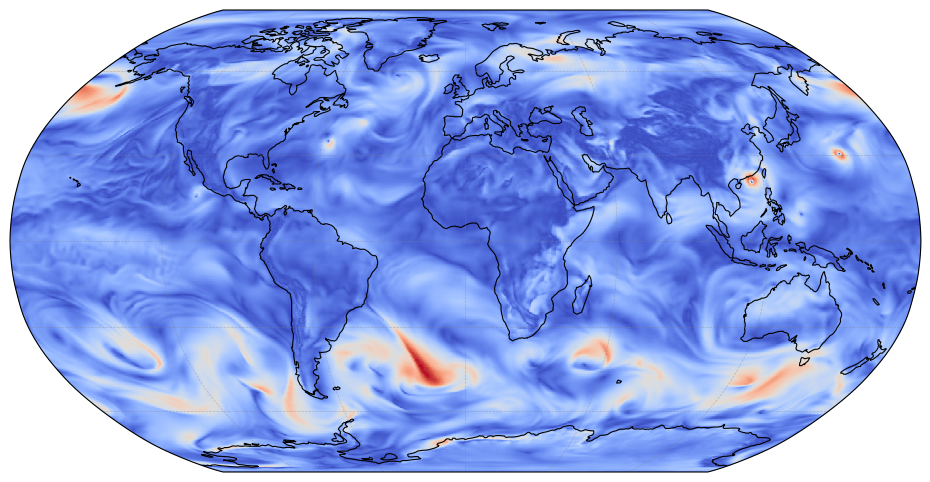

In [ ]:
u850_pangu = pangu_24h.u.sel(valid_time="2025-09-23T19:00:00", level=3).data
v850_pangu = pangu_24h.v.sel(valid_time="2025-09-23T19:00:00", level=3).data
wspd850_pangu = np.sqrt(u850_pangu**2 + v850_pangu**2)

lat = pangu_24h.latitude.data
lon = pangu_24h.longitude.data
wspd850_pangu_cyclic, lon_cyclic = add_cyclic_point(wspd850_pangu, coord=lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
mesh = ax.pcolormesh(
    lon_cyclic,
    lat,
    wspd850_pangu_cyclic,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    shading="auto",
)
ax.set_global()
ax.coastlines(linewidth=0.8)
# ax.gridlines(linewidth=0.5, color="gray", alpha=0.4, linestyle="--")

plt.savefig("wspd850_pangu_2025092319.tif", dpi=600, bbox_inches="tight")
plt.show()

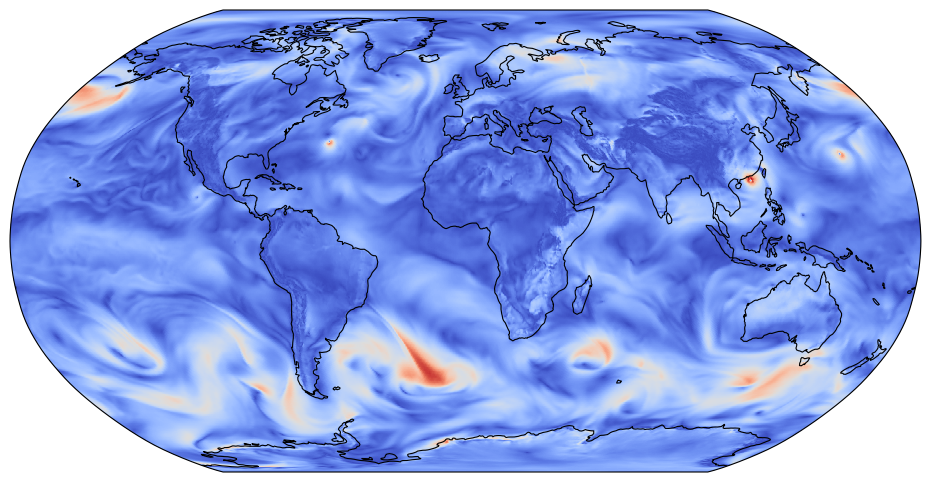

In [5]:
u850_graphcast = graphcast_24h["u_component_of_wind"].sel(level=850).isel(batch=0, time=0).data
v850_graphcast = graphcast_24h["v_component_of_wind"].sel(level=850).isel(batch=0, time=0).data
wspd850_graphcast = np.sqrt(u850_graphcast**2 + v850_graphcast**2)

lat = graphcast_24h.lat.data
lon = graphcast_24h.lon.data
wspd850_graphcast_cyclic, lon_cyclic = add_cyclic_point(wspd850_graphcast, coord=lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
mesh = ax.pcolormesh(
    lon_cyclic,
    lat,
    wspd850_graphcast_cyclic,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    shading="auto",
)
ax.set_global()
ax.coastlines(linewidth=0.8)

plt.savefig("wspd850_graphcast_2025092319.tif", dpi=600, bbox_inches="tight")
plt.show()

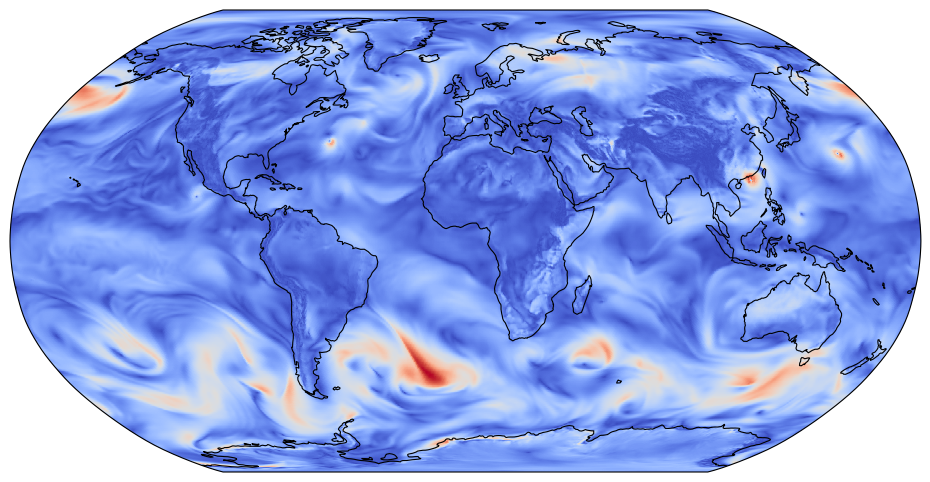

In [11]:
u850_fengwu = fengwu_24h.u850.isel(valid_time=0).data
v850_fengwu = fengwu_24h.v850.isel(valid_time=0).data
wspd850_fengwu = np.sqrt(u850_fengwu**2 + v850_fengwu**2)

lat = fengwu_24h.latitude.data
lon = fengwu_24h.longitude.data
wspd850_fengwu_cyclic, lon_cyclic = add_cyclic_point(wspd850_fengwu, coord=lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
mesh = ax.pcolormesh(
    lon_cyclic,
    lat,
    wspd850_fengwu_cyclic,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    shading="auto",
)
ax.set_global()
ax.coastlines(linewidth=0.8)

plt.savefig("wspd850_fengwu_2025092319.tif", dpi=600, bbox_inches="tight")
plt.show()

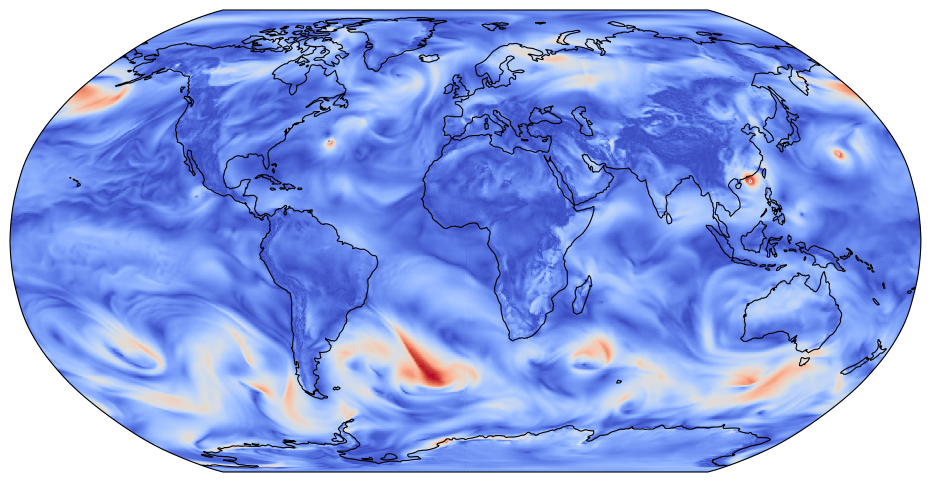

In [12]:
fuxi_field = fuxi_24h["__xarray_dataarray_variable__"]
u850_fuxi = fuxi_field.sel(level="U850").isel(time=0, step=0).data
v850_fuxi = fuxi_field.sel(level="V850").isel(time=0, step=0).data
wspd850_fuxi = np.sqrt(u850_fuxi**2 + v850_fuxi**2)

lat = fuxi_24h.lat.data
lon = fuxi_24h.lon.data
wspd850_fuxi_cyclic, lon_cyclic = add_cyclic_point(wspd850_fuxi, coord=lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
mesh = ax.pcolormesh(
    lon_cyclic,
    lat,
    wspd850_fuxi_cyclic,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    shading="auto",
)
ax.set_global()
ax.coastlines(linewidth=0.8)

plt.savefig("wspd850_fuxi_2025092319.tif", dpi=600, bbox_inches="tight")
plt.show()

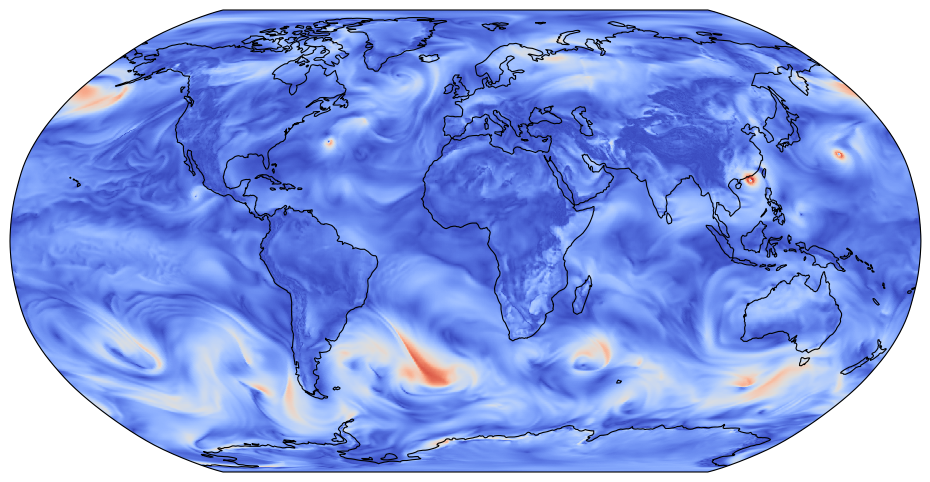

In [13]:
u850_aurora = aurora_24h.u.sel(level=850).data
v850_aurora = aurora_24h.v.sel(level=850).data
wspd850_aurora = np.sqrt(u850_aurora**2 + v850_aurora**2)

lat = aurora_24h.lat.data
lon = aurora_24h.lon.data
wspd850_aurora_cyclic, lon_cyclic = add_cyclic_point(wspd850_aurora, coord=lon)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson())
mesh = ax.pcolormesh(
    lon_cyclic,
    lat,
    wspd850_aurora_cyclic,
    transform=ccrs.PlateCarree(),
    cmap="coolwarm",
    shading="auto",
)
ax.set_global()
ax.coastlines(linewidth=0.8)

plt.savefig("wspd850_aurora_2025092319.tif", dpi=600, bbox_inches="tight")
plt.show()

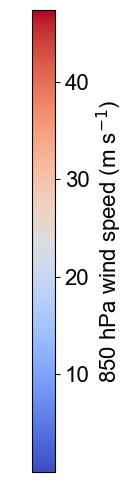

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

if "era5_uv850_20250923_19" not in globals():
    era5_uv850_20250923_19 = xr.open_dataset("./data/era5_uv850_20250923-19.nc")

u850_era5 = era5_uv850_20250923_19.u.data.squeeze()
v850_era5 = era5_uv850_20250923_19.v.data.squeeze()
wspd850_era5 = np.sqrt(u850_era5**2 + v850_era5**2)

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 16

norm = mpl.colors.Normalize(
    vmin=float(np.nanmin(wspd850_era5)),
    vmax=float(np.nanmax(wspd850_era5)),
)
sm = mpl.cm.ScalarMappable(norm=norm, cmap="coolwarm")
sm.set_array([])

fig, ax = plt.subplots(figsize=(1.4, 6))
ax.set_axis_off()
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.8, pad=0.02)
cbar.set_label("850 hPa wind speed (m s$^{-1}$)", fontsize=16, family="Arial")
cbar.ax.tick_params(labelsize=16)
for tick_label in cbar.ax.get_yticklabels():
    tick_label.set_fontfamily("Arial")

plt.savefig("wspd850_era5_colorbar_vertical.tif")
plt.show()